# **MNIST Classification using FCNN and CNN in PyTorch**
--------------------------------------------------
This tutorial demonstrates how to:

* Load and preprocess the MNIST dataset
* Build two models - FCNN and CNN
* Train and evaluate the models
* Save and load trained models
* Compute confusion matrix, precision, recall, and F1-score
* Plot training loss vs epochs




# **1. IMPORT LIBRARIES**

In [1]:
import os
import cv2
import numpy as np
import seaborn as sns
import random as rand
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report

import torch
from torch import nn, optim, Tensor
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision import transforms

# **2. SETUP**

In [2]:
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cuda


# **3. LOAD AND PREPROCESS MNIST DATA**

In [3]:
class MNIST(Dataset):
    def __init__(
            self, 
            num_labels:int, 
            img_pre_process=None, 
            path_dir:str="MNIST/Images/train", 
            file_ext:str=".jpg"
        )->None:
        super().__init__()
        self.path_dir = path_dir
        self.num_labels = num_labels
        self.img_pre_process = img_pre_process if img_pre_process is not None else transforms.Compose([
                                                                                        transforms.Normalize((0.1307,), (0.3081,))
                                                                                    ])

        if not self.verify_dir():
            raise FileNotFoundError("Unable to find the labels in MNIST")
        
        self.img_path = glob(os.path.join(self.path_dir, f"**/*{file_ext}"))
        self.label = {label:tag for tag, label in enumerate(os.listdir(self.path_dir))}

    def verify_dir(self,)->bool:
        path_dir = os.listdir(self.path_dir)
        if len(path_dir)==self.num_labels:
            return True
        else:
            return False
    
    def __len__(self):
        return len(self.img_path)
    
    def load_image(self, path:str)->Tensor:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Unable to find the image at path {path}")
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img_tensor = torch.from_numpy(img).to(torch.float32)
        img_tensor = torch.unsqueeze(img_tensor, dim=0)
        return self.img_pre_process(img_tensor)

    def __getitem__(self, idx):
        path = self.img_path[idx]
        img_tensor = self.load_image(path)
        label = self.label[path.split("/")[-2]]
        label = torch.tensor(label).to(torch.long)
        return img_tensor, label
        

In [4]:
train_dataset = MNIST(num_labels=10, path_dir="MNIST/Images/train")
test_dataset  = MNIST(num_labels=10, path_dir="MNIST/Images/test")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Training samples: {len(train_dataset)}")
print(f"✅ Testing samples : {len(test_dataset)}")

✅ Training samples: 30360
✅ Testing samples : 7590


In [5]:
for train_batch, test_batch in zip(train_loader, test_loader):
    break


In [6]:
train_batch[0].shape, train_batch[1].shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

# **4. MODEL DEFINITIONS**

In [7]:
class FCNN(nn.Module):
    def __init__(self, input_size=784, num_classes=10):
        super(FCNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class SimpleCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(64 * 7 * 7, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# **5. TRAINING AND TESTING FUNCTIONS**

In [8]:
def train_model(model, train_loader, optimizer, epoch):
    """Train model for one epoch and return average loss"""
    model.train()
    running_loss = 0.0
    for data, target in tqdm(train_loader):
        data, target = data.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    print(f"🧠 Epoch [{epoch}] - Train Loss: {avg_loss:.4f}")
    return avg_loss

@torch.no_grad()
def test_model(model, test_loader):
    """Evaluate model and compute accuracy"""
    model.eval()
    test_loss, correct = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for data, target in tqdm(test_loader):
            data, target = data.to(DEVICE), target.to(DEVICE)
            output = model(data)
            test_loss += F.cross_entropy(output, target, reduction='sum').item()
            preds = output.argmax(dim=1)
            correct += preds.eq(target).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(target.cpu().numpy())
    test_loss /= len(test_loader.dataset)
    acc = 100. * correct / len(test_loader.dataset)
    print(f"✅ Test Loss: {test_loss:.4f} | Accuracy: {acc:.2f}%")
    return acc, np.array(all_preds), np.array(all_labels)

# **6. TRAIN FCNN MODEL**

In [9]:
print("\n===============================")
print("🚀 TRAINING FCNN MODEL")
print("===============================")

fcnn_model = FCNN().to(DEVICE)
fcnn_optimizer = optim.Adam(fcnn_model.parameters(), lr=LEARNING_RATE)
fcnn_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    loss = train_model(fcnn_model, train_loader, fcnn_optimizer, epoch)
    fcnn_losses.append(loss)

torch.save(fcnn_model.state_dict(), "fcnn_mnist.pth")
print("💾 FCNN model saved as 'fcnn_mnist.pth'")

fcnn_acc, fcnn_preds, fcnn_labels = test_model(fcnn_model, test_loader)


🚀 TRAINING FCNN MODEL


100%|██████████| 949/949 [00:03<00:00, 275.24it/s]


🧠 Epoch [1] - Train Loss: 0.8391


100%|██████████| 949/949 [00:03<00:00, 274.79it/s]


🧠 Epoch [2] - Train Loss: 0.2408


...

🧠 Epoch [19] - Train Loss: 0.1018


100%|██████████| 949/949 [00:02<00:00, 343.05it/s]


🧠 Epoch [20] - Train Loss: 0.0735
💾 FCNN model saved as 'fcnn_mnist.pth'


100%|██████████| 238/238 [00:00<00:00, 611.51it/s]

✅ Test Loss: 0.2778 | Accuracy: 95.67%


# **7. TRAIN CNN MODEL**

In [10]:
# ======================================================
# 7. TRAIN CNN MODEL
# ======================================================
print("\n===============================")
print("🚀 TRAINING CNN MODEL")
print("===============================")

cnn_model = SimpleCNN().to(DEVICE)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)
cnn_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    loss = train_model(cnn_model, train_loader, cnn_optimizer, epoch)
    cnn_losses.append(loss)

# Save CNN model
torch.save(cnn_model.state_dict(), "cnn_mnist.pth")
print("💾 CNN model saved as 'cnn_mnist.pth'")

# Evaluate CNN
cnn_acc, cnn_preds, cnn_labels = test_model(cnn_model, test_loader)


🚀 TRAINING CNN MODEL


100%|██████████| 949/949 [00:03<00:00, 240.05it/s]


🧠 Epoch [1] - Train Loss: 1.0521


100%|██████████| 949/949 [00:03<00:00, 241.53it/s]


🧠 Epoch [2] - Train Loss: 0.1586


...

🧠 Epoch [19] - Train Loss: 0.0480


100%|██████████| 949/949 [00:02<00:00, 332.39it/s]


🧠 Epoch [20] - Train Loss: 0.0397
💾 CNN model saved as 'cnn_mnist.pth'


100%|██████████| 238/238 [00:00<00:00, 640.10it/s]

✅ Test Loss: 0.2729 | Accuracy: 97.91%


# **8. PLOT EPOCH VS LOSS CURVES**

/home/chaitanya-kohli/miniconda3/envs/torch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


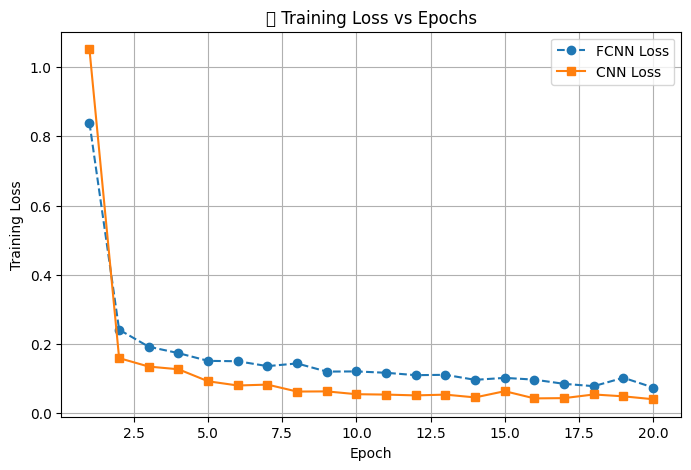

In [11]:
# ======================================================
# 8. PLOT EPOCH VS LOSS CURVES
# ======================================================
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), fcnn_losses, 'o--', label='FCNN Loss')
plt.plot(range(1, NUM_EPOCHS + 1), cnn_losses, 's-', label='CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('📉 Training Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

# **9. EVALUATION: CONFUSION MATRIX & METRICS (CNN)**


📊 CNN MODEL PERFORMANCE METRICS
--------------------------------
              precision    recall  f1-score   support

           0     0.9906    0.9723    0.9814       759
           1     0.9844    0.9947    0.9895       759
           2     0.9866    0.9736    0.9801       759
           3     0.9650    0.9816    0.9732       759
           4     0.9792    0.9908    0.9849       759
           5     0.9761    0.9671    0.9715       759
           6     0.9776    0.9763    0.9769       759
           7     0.9789    0.9802    0.9796       759
           8     0.9867    0.9763    0.9815       759
           9     0.9661    0.9776    0.9718       759

    accuracy                         0.9791      7590
   macro avg     0.9791    0.9791    0.9791      7590
weighted avg     0.9791    0.9791    0.9791      7590



/home/chaitanya-kohli/miniconda3/envs/torch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


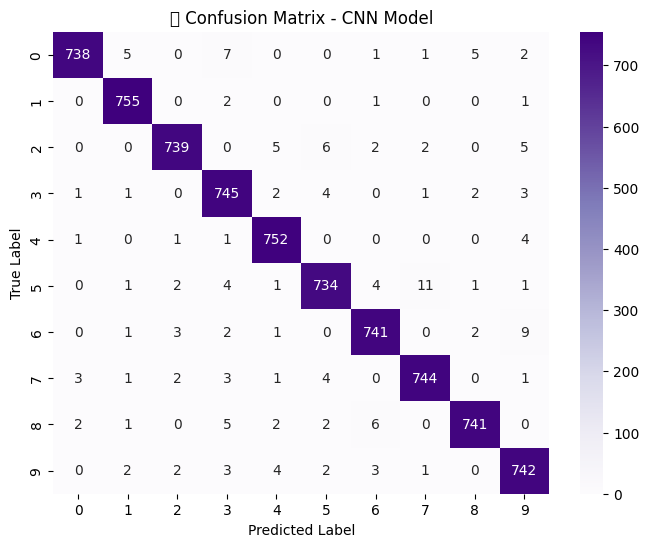

In [12]:
# ======================================================
# 9. EVALUATION: CONFUSION MATRIX & METRICS (CNN)
# ======================================================
print("\n📊 CNN MODEL PERFORMANCE METRICS")
print("--------------------------------")
print(classification_report(cnn_labels, cnn_preds, digits=4))

cm = confusion_matrix(cnn_labels, cnn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])
plt.title("🧩 Confusion Matrix - CNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


📊 FCNN MODEL PERFORMANCE METRICS
--------------------------------
              precision    recall  f1-score   support

           0     0.9815    0.9763    0.9789       759
           1     0.9751    0.9816    0.9783       759
           2     0.9593    0.9618    0.9605       759
           3     0.9295    0.9038    0.9165       759
           4     0.9702    0.9881    0.9791       759
           5     0.9247    0.9552    0.9397       759
           6     0.9646    0.9341    0.9491       759
           7     0.9683    0.9644    0.9663       759
           8     0.9674    0.9381    0.9525       759
           9     0.9277    0.9631    0.9451       759

    accuracy                         0.9567      7590
   macro avg     0.9568    0.9567    0.9566      7590
weighted avg     0.9568    0.9567    0.9566      7590



/home/chaitanya-kohli/miniconda3/envs/torch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


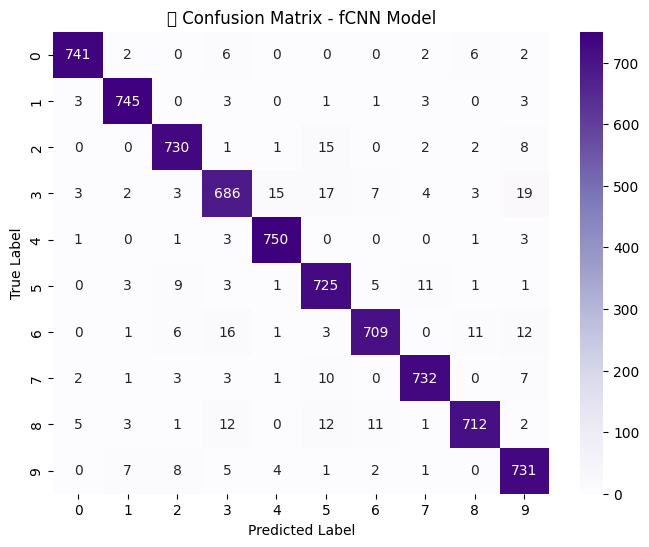

In [15]:
# ======================================================
# 9. EVALUATION: CONFUSION MATRIX & METRICS (CNN)
# ======================================================
print("\n📊 FCNN MODEL PERFORMANCE METRICS")
print("--------------------------------")
print(classification_report(fcnn_labels, fcnn_preds, digits=4))

cm = confusion_matrix(fcnn_labels, fcnn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])
plt.title("🧩 Confusion Matrix - fCNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# **10. LOAD SAVED MODEL & VERIFY**

In [13]:
print("\n📦 Loading saved CNN model and re-evaluating...")
loaded_cnn = SimpleCNN().to(DEVICE)
loaded_cnn.load_state_dict(torch.load("cnn_mnist.pth"))
loaded_cnn.eval()
_, loaded_preds, loaded_labels = test_model(loaded_cnn, test_loader)
print("✅ Model reloaded successfully and produces same accuracy!")


📦 Loading saved CNN model and re-evaluating...


100%|██████████| 238/238 [00:00<00:00, 604.04it/s]

✅ Test Loss: 0.2729 | Accuracy: 97.91%
✅ Model reloaded successfully and produces same accuracy!


# **11. FINAL RESULTS SUMMARY**

In [14]:
# ======================================================
# 11. FINAL RESULTS SUMMARY
# ======================================================
print("\n===============================")
print("🏁 FINAL RESULTS SUMMARY")
print("===============================")
print(f"FCNN Accuracy: {fcnn_acc:.2f}%")
print(f"CNN Accuracy : {cnn_acc:.2f}%")

if cnn_acc > fcnn_acc:
    print("\n🎯 CNN outperforms FCNN — it captures spatial features better!")
else:
    print("\n⚠️ FCNN performed better — try increasing epochs or tuning hyperparameters.")


🏁 FINAL RESULTS SUMMARY
FCNN Accuracy: 95.67%
CNN Accuracy : 97.91%

🎯 CNN outperforms FCNN — it captures spatial features better!
